In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/LA4PSchools.csv")

In [ ]:
df.head(25)
#it will return the first 25 rows of the dataset

,StudentID,Gender,Year_02,Kinder_Age,Disability,NCCD-Funded,01.SES,02.SES,NumSibling,SiblingOrder,...,HRSIW-01-SOY,Counting-01,Counting-02,Place Value-01,Place Value-02,Addition and Subtraction-01,Addition and Subtraction-02,Multiplication and Division-01,Multiplication and Division-02,Year3_Writing_At_Risk
0,SN35433053,Male,2020,5.5,Disability_Non-disable,0,104,104,3,3,...,49,4,5,2,2,2,4,2,2,False
1,SN71277215,Female,2018,5.8,Disability_Non-disable,0,112,112,2,2,...,37,2,1,1,1,2,3,0,2,False
2,SN40883127,Male,2021,5.9,Disability_Non-disable,0,120,109,2,2,...,30,2,1,1,2,2,1,2,1,False
3,SN93063777,Male,2021,5.7,Disability_Non-disable,0,95,93,2,1,...,30,2,3,1,2,1,5,2,2,False
4,SN84195329,Male,2021,5.8,Disability_Non-disable,0,98,98,1,1,...,32,2,4,2,2,2,4,1,1,True
5,SN89893958,Female,2016,5.3,Disability_Non-disable,0,104,104,4,3,...,40,2,4,2,2,1,2,1,3,True
6,SN00499342,Male,2020,5.1,Disability_Non-disable,0,110,110,2,1,...,51,2,2,1,1,0,2,0,2,False
7,SN20235426,Female,2020,5.6,Disability_Non-disable,0,109,109,2,1,...,28,0,0,1,1,1,1,0,1,False
8,SN14781526,Female,2016,5.6,Disability_Non-disable,0,120,120,1,1,...,39,1,5,1,2,2,2,2,2,False
9,SN42469492,Female,2020,4.9,Disability_Non-disable,0,107,107,2,2,...,16,0,3,1,1,1,1,1,1,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   StudentID                       2000 non-null   object 
 1   Gender                          2000 non-null   object 
 2   Year_02                         2000 non-null   int64  
 3   Kinder_Age                      2000 non-null   float64
 4   Disability                      2000 non-null   object 
 5   NCCD-Funded                     2000 non-null   int64  
 6   01.SES                          2000 non-null   int64  
 7   02.SES                          2000 non-null   int64  
 8   NumSibling                      2000 non-null   int64  
 9   SiblingOrder                    2000 non-null   int64  
 10  NumAbvYear9                     2000 non-null   int64  
 11  NumAbvDiploma                   2000 non-null   int64  
 12  NumProf                         20

In [ ]:
categorical_cols = df.select_dtypes('object').columns.tolist()
categorical_cols

['StudentID', 'Gender', 'Disability']

In [ ]:
df.columns

Index(['StudentID', 'Gender', 'Year_02', 'Kinder_Age', 'Disability',
       'NCCD-Funded', '01.SES', '02.SES', 'NumSibling', 'SiblingOrder',
       'NumAbvYear9', 'NumAbvDiploma', 'NumProf', 'Burt-01-SOY', 'Burt-01-EOY',
       'Clay-01-SOY', 'Clay-01-EOY', 'TextLevel-01-SOY', 'TextLevel-01-MOY',
       'TextLevel-01-EOY', 'TextLevel-02-SOY', 'TextLevel-02-MOY',
       'TextLevel-02-EOY', 'WritingVocab-01-SOY', 'HRSIW-01-SOY',
       'Counting-01', 'Counting-02', 'Place Value-01', 'Place Value-02',
       'Addition and Subtraction-01', 'Addition and Subtraction-02',
       'Multiplication and Division-01', 'Multiplication and Division-02',
       'Year3_Writing_At_Risk'],
      dtype='object')

In [ ]:
print("Checking for duplicates:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Checking for duplicates:
Number of duplicate rows: 0


In [ ]:
print("Descriptive Statistics (Numerical Columns):")
print(df.describe())

Descriptive Statistics (Numerical Columns):
           Year_02   Kinder_Age  NCCD-Funded     01.SES       02.SES  \
count  2000.000000  2000.000000  2000.000000  2000.0000  2000.000000   
mean   2018.640000     5.276400     0.089000   102.9415   102.117500   
std       1.664568     0.348129     0.284815     9.3859     9.150167   
min    2016.000000     4.500000     0.000000    78.0000    78.000000   
25%    2017.000000     5.000000     0.000000    95.0000    95.000000   
50%    2018.000000     5.300000     0.000000   101.0000   101.000000   
75%    2020.000000     5.500000     0.000000   113.0000   109.000000   
max    2021.000000     6.500000     1.000000   120.0000   120.000000   

        NumSibling  SiblingOrder  NumAbvYear9  NumAbvDiploma      NumProf  \
count  2000.000000   2000.000000  2000.000000    2000.000000  2000.000000   
mean      2.356500      1.748500     1.564000       0.886500     0.766500   
std       0.993932      0.865229     0.725374       0.837836     0.811977   

In [ ]:
# Unique values in categorical columns
print("Unique Values in Categorical Columns:")
categorical_columns = ['Gender', 'Disability', 'Year3_Writing_At_Risk']
for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")

Unique Values in Categorical Columns:
Gender: ['Male' 'Female']
Disability: ['Disability_Non-disable' 'Disability_Physical' 'Disability_Cognitive'
 'Disability_SocialEmotional' 'Disability_Sensory']
Year3_Writing_At_Risk: [False  True]


In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Disability'] = df['Disability'].map({
    'Disability_Non-disable': 0,
    'Disability_Cognitive': 1,
    'Disability_Physical': 2,
    'Disability_Sensory': 3,
    'Disability_Social-Emotional': 4
})

In [ ]:
print("Data Types after Preprocessing:")
print(df.dtypes)

Data Types after Preprocessing:
StudentID                          object
Gender                              int64
Year_02                             int64
Kinder_Age                        float64
Disability                        float64
NCCD-Funded                         int64
01.SES                              int64
02.SES                              int64
NumSibling                          int64
SiblingOrder                        int64
NumAbvYear9                         int64
NumAbvDiploma                       int64
NumProf                             int64
Burt-01-SOY                         int64
Burt-01-EOY                         int64
Clay-01-SOY                         int64
Clay-01-EOY                         int64
TextLevel-01-SOY                    int64
TextLevel-01-MOY                    int64
TextLevel-01-EOY                    int64
TextLevel-02-SOY                    int64
TextLevel-02-MOY                    int64
TextLevel-02-EOY                    int64
Wr

In [ ]:
df = df.drop(columns=['StudentID'])

What are the SES backgrounds of the students in the dataset in Year 1 and Year 2? FYI, in 2018 the
Catholic system schools have a national average SES of 100 while independent schools have an average
SES of 102, according to the Australian Department of Education and Training.

In [ ]:
df[['01.SES', '02.SES']].describe()

,01.SES,02.SES
count,2000.0000,2000.000000
mean,102.9415,102.117500
std,9.3859,9.150167
min,78.0000,78.000000
25%,95.0000,95.000000
50%,101.0000,101.000000
75%,113.0000,109.000000
max,120.0000,120.000000


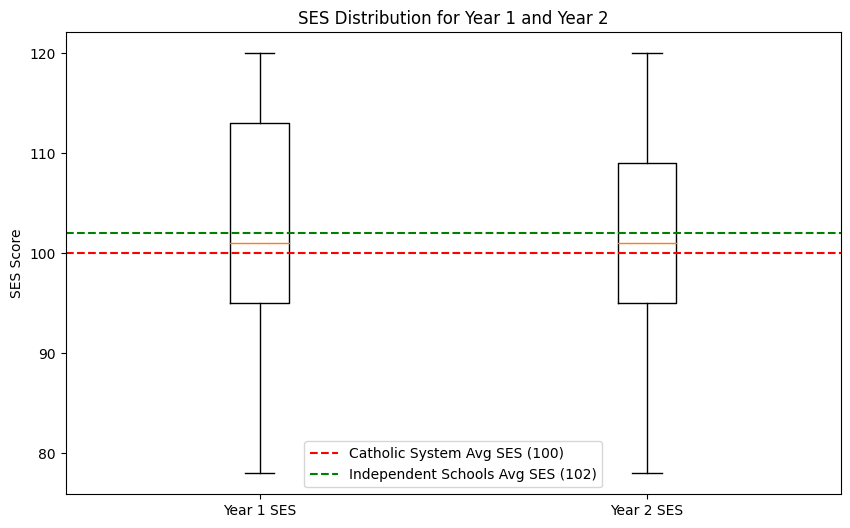

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot([df['01.SES'], df['02.SES']], labels=['Year 1 SES', 'Year 2 SES'])
plt.axhline(y=100, color='red', linestyle='--', label='Catholic System Avg SES (100)')
plt.axhline(y=102, color='green', linestyle='--', label='Independent Schools Avg SES (102)')
plt.title('SES Distribution for Year 1 and Year 2')
plt.ylabel('SES Score')
plt.legend()
plt.show()

What are students’ reading skills, for example, Burt Reading Scores, at the start and end of Year 1 and
at the start and end of Year 2?

In [ ]:
df[['Burt-01-SOY', 'Burt-01-EOY']].describe()

,Burt-01-SOY,Burt-01-EOY
count,2000.000000,2000.000000
mean,21.382500,36.574000
std,11.178715,12.260534
min,0.000000,0.000000
25%,14.000000,29.000000
50%,21.000000,33.000000
75%,28.000000,43.000000
max,77.000000,101.000000


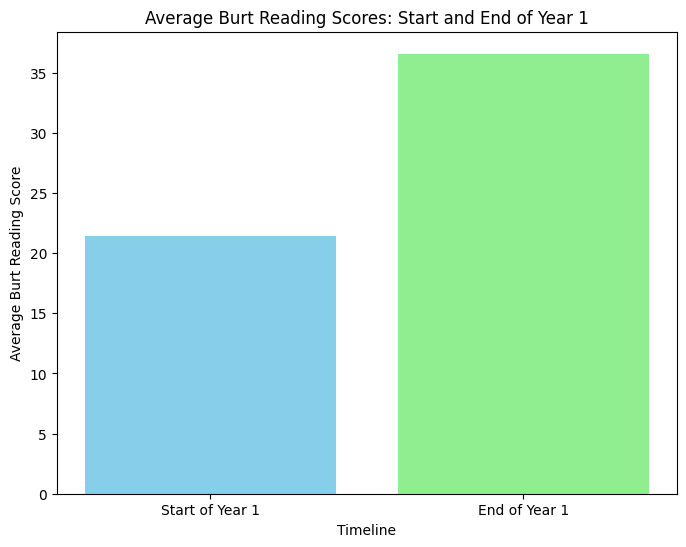

In [ ]:
burt_means = {
    'Start of Year 1': df['Burt-01-SOY'].mean(),
    'End of Year 1': df['Burt-01-EOY'].mean()
}
plt.figure(figsize=(8, 6))
plt.bar(burt_means.keys(), burt_means.values(), color=['skyblue', 'lightgreen'])
plt.title('Average Burt Reading Scores: Start and End of Year 1')
plt.xlabel('Timeline')
plt.ylabel('Average Burt Reading Score')
plt.show()

What are students’ writing skills at the start of Year 1, WritingVocab-01-SOY? Is there a relationship
between this and Year3_Writing_At_Risk?

In [ ]:
df['WritingVocab-01-SOY'].describe()

,WritingVocab-01-SOY
count,2000.000000
mean,22.018500
std,12.679098
min,0.000000
25%,13.000000
50%,20.000000
75%,29.000000
max,95.000000


In [ ]:
at_risk_means = df.groupby('Year3_Writing_At_Risk')['WritingVocab-01-SOY'].mean()
print("Mean Writing Vocabulary Scores:")
print(at_risk_means)

Mean Writing Vocabulary Scores:
Year3_Writing_At_Risk
False    25.131184
True     15.783784
Name: WritingVocab-01-SOY, dtype: float64


<ipython-input-20-c04ac28da2a9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year3_Writing_At_Risk', y='WritingVocab-01-SOY', data=df, palette="Set2")
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1

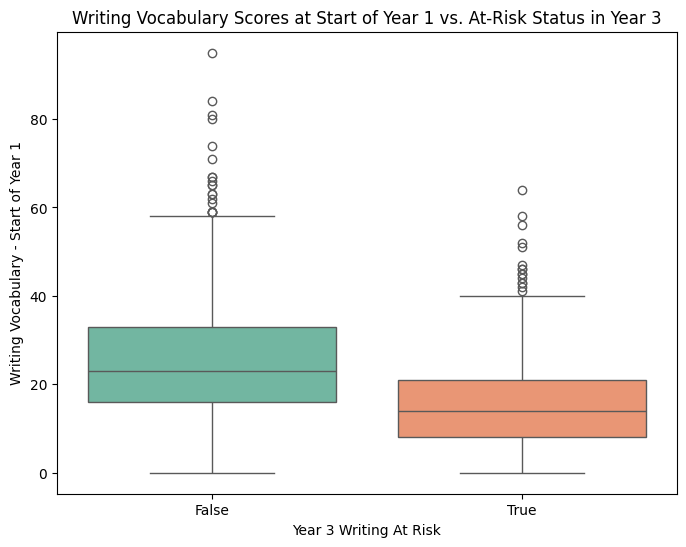

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Year3_Writing_At_Risk', y='WritingVocab-01-SOY', data=df, palette="Set2")
plt.title('Writing Vocabulary Scores at Start of Year 1 vs. At-Risk Status in Year 3')
plt.xlabel('Year 3 Writing At Risk')
plt.ylabel('Writing Vocabulary - Start of Year 1')
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu
at_risk_true = df[df['Year3_Writing_At_Risk'] == True]['WritingVocab-01-SOY']
at_risk_false = df[df['Year3_Writing_At_Risk'] == False]['WritingVocab-01-SOY']
u_stat, p_value_mw = mannwhitneyu(at_risk_true, at_risk_false)

print(f"Mann-Whitney U Test Results: U-statistic = {u_stat}, p-value = {p_value_mw}")

Mann-Whitney U Test Results: U-statistic = 241459.0, p-value = 2.3647350679386536e-62


4. Are students’ literacy skills and numeracy skills related? And are there relationships between these
and their Year3_Writing_At_Risk?

In [ ]:
reading_cols = ['Burt-01-SOY', 'Burt-01-EOY', 'Clay-01-SOY', 'Clay-01-EOY']
math_cols = ['Counting-01', 'Counting-02', 'Place Value-01', 'Place Value-02']

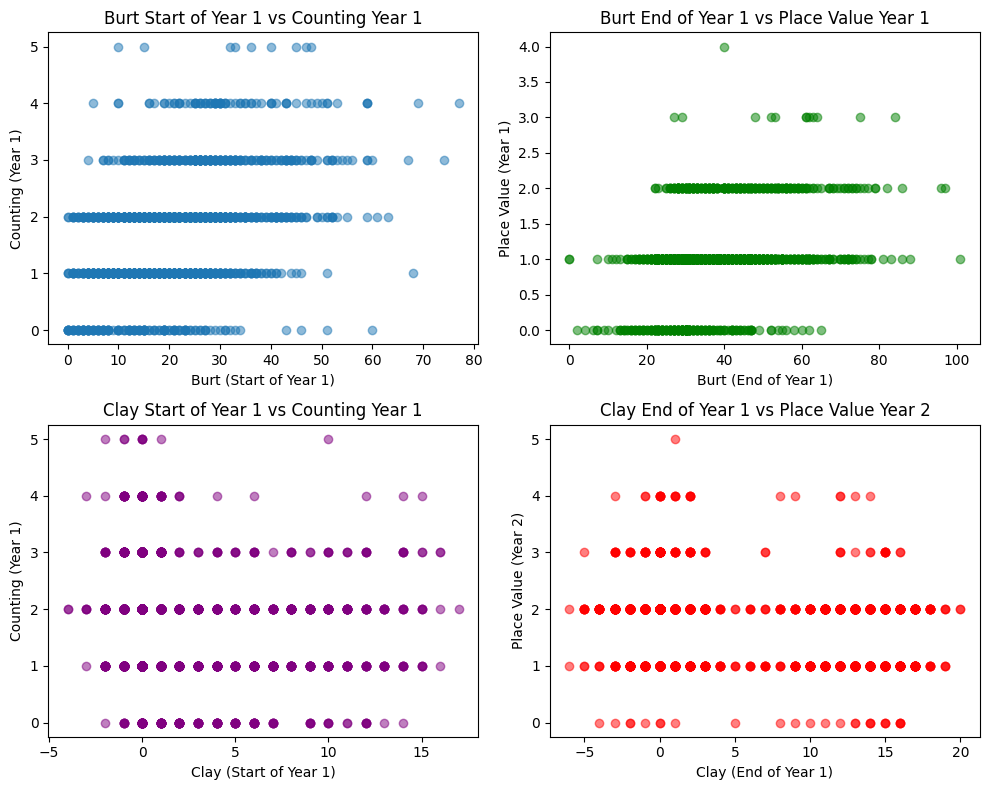

In [ ]:
plt.figure(figsize=(10, 8))

# Scatter plot for Burt-01-SOY (Literacy) vs Counting-01 (Numeracy)
plt.subplot(2, 2, 1)
plt.scatter(df['Burt-01-SOY'], df['Counting-01'], alpha=0.5)
plt.title('Burt Start of Year 1 vs Counting Year 1')
plt.xlabel('Burt (Start of Year 1)')
plt.ylabel('Counting (Year 1)')

# Scatter plot for Burt-01-EOY (Literacy) vs Place Value-01 (Numeracy)
plt.subplot(2, 2, 2)
plt.scatter(df['Burt-01-EOY'], df['Place Value-01'], alpha=0.5, color='green')
plt.title('Burt End of Year 1 vs Place Value Year 1')
plt.xlabel('Burt (End of Year 1)')
plt.ylabel('Place Value (Year 1)')

# Scatter plot for Clay-01-SOY (Literacy) vs Counting-01 (Numeracy)
plt.subplot(2, 2, 3)
plt.scatter(df['Clay-01-SOY'], df['Counting-01'], alpha=0.5, color='purple')
plt.title('Clay Start of Year 1 vs Counting Year 1')
plt.xlabel('Clay (Start of Year 1)')
plt.ylabel('Counting (Year 1)')

# Scatter plot for Clay-01-EOY (Literacy) vs Place Value-02 (Numeracy)
plt.subplot(2, 2, 4)
plt.scatter(df['Clay-01-EOY'], df['Place Value-02'], alpha=0.5, color='red')
plt.title('Clay End of Year 1 vs Place Value Year 2')
plt.xlabel('Clay (End of Year 1)')
plt.ylabel('Place Value (Year 2)')

plt.tight_layout()
plt.show()

In [ ]:
print("Correlation between Reading and Math Skills:")
reading_math_corr = df[reading_cols + math_cols].corr()
print(reading_math_corr)

Correlation between Reading and Math Skills:
                Burt-01-SOY  Burt-01-EOY  Clay-01-SOY  Clay-01-EOY  \
Burt-01-SOY        1.000000     0.801720    -0.230812    -0.530495   
Burt-01-EOY        0.801720     1.000000    -0.164600    -0.379514   
Clay-01-SOY       -0.230812    -0.164600     1.000000     0.502755   
Clay-01-EOY       -0.530495    -0.379514     0.502755     1.000000   
Counting-01        0.415672     0.385477    -0.138487    -0.285077   
Counting-02        0.389691     0.352159    -0.100185    -0.238409   
Place Value-01     0.375713     0.328325    -0.066027    -0.213501   
Place Value-02     0.354698     0.319318    -0.044532    -0.220596   

                Counting-01  Counting-02  Place Value-01  Place Value-02  
Burt-01-SOY        0.415672     0.389691        0.375713        0.354698  
Burt-01-EOY        0.385477     0.352159        0.328325        0.319318  
Clay-01-SOY       -0.138487    -0.100185       -0.066027       -0.044532  
Clay-01-EOY       -0.285

Describe the students’ disability conditions in the dataset. And are there relationships between these
conditions and their Year3_Writing_At_Risk?

In [ ]:
disability_counts = df['Disability'].value_counts()

print("Disability Condition Counts:")
print(disability_counts)

Disability Condition Counts:
Disability
0.0    1381
1.0     469
2.0      67
3.0      10
Name: count, dtype: int64


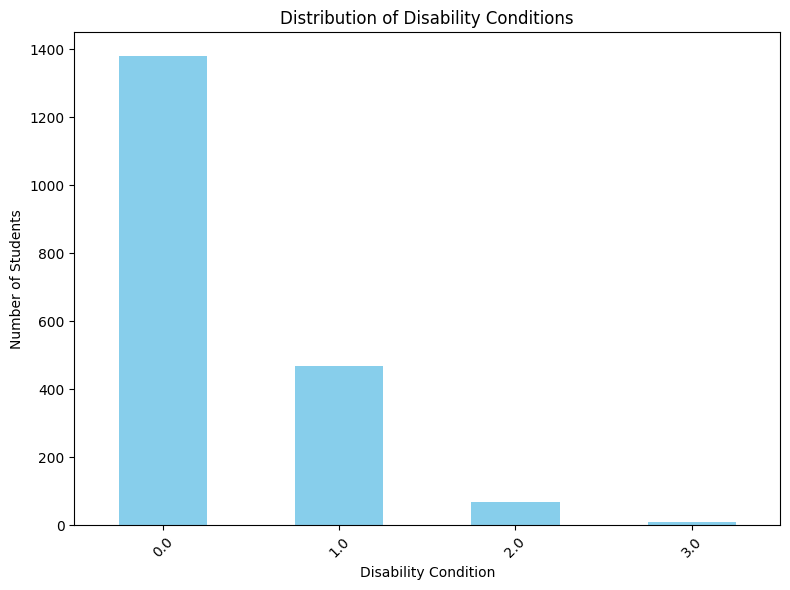

In [ ]:
plt.figure(figsize=(8, 6))
disability_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Disability Conditions')
plt.xlabel('Disability Condition')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(df['Disability'], df['Year3_Writing_At_Risk'])
print("Contingency Table for Disability vs Year3_Writing_At_Risk:")
print(contingency_table)

Contingency Table for Disability vs Year3_Writing_At_Risk:
Year3_Writing_At_Risk  False  True 
Disability                         
0.0                     1027    354
1.0                      212    257
2.0                       49     18
3.0                        7      3


Are there other insights that might inform early interventions to improve students’ writing skills?

In [ ]:
# Correlation matrix for literacy skills and writing risk
literacy_columns = ['Burt-01-SOY', 'Clay-01-SOY', 'TextLevel-01-SOY', 'WritingVocab-01-SOY']
correlation_matrix = df[literacy_columns + ['Year3_Writing_At_Risk']].corr()

print("Correlation between Early Literacy Skills and Year3_Writing_At_Risk:")
print(correlation_matrix)

Correlation between Early Literacy Skills and Year3_Writing_At_Risk:
                       Burt-01-SOY  Clay-01-SOY  TextLevel-01-SOY  \
Burt-01-SOY               1.000000    -0.230812          0.810907   
Clay-01-SOY              -0.230812     1.000000         -0.277872   
TextLevel-01-SOY          0.810907    -0.277872          1.000000   
WritingVocab-01-SOY       0.624243    -0.141453          0.583852   
Year3_Writing_At_Risk    -0.363366     0.074842         -0.347630   

                       WritingVocab-01-SOY  Year3_Writing_At_Risk  
Burt-01-SOY                       0.624243              -0.363366  
Clay-01-SOY                      -0.141453               0.074842  
TextLevel-01-SOY                  0.583852              -0.347630  
WritingVocab-01-SOY               1.000000              -0.347533  
Year3_Writing_At_Risk            -0.347533               1.000000  


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


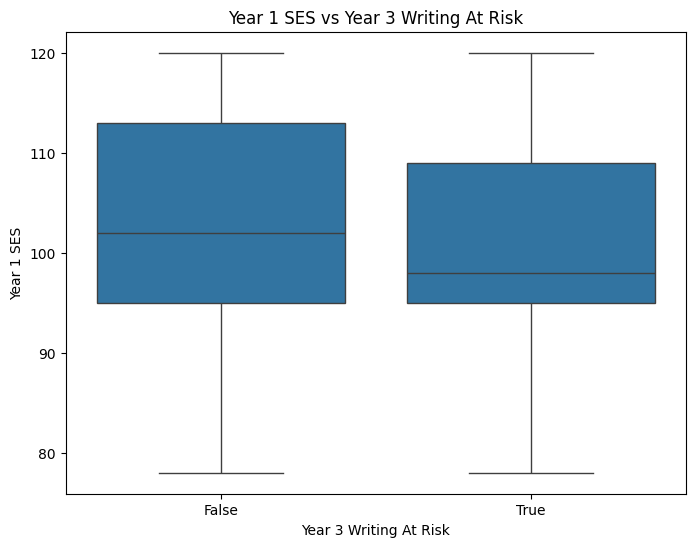

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Year3_Writing_At_Risk', y='01.SES', data=df)
plt.title('Year 1 SES vs Year 3 Writing At Risk')
plt.xlabel('Year 3 Writing At Risk')
plt.ylabel('Year 1 SES')
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2000 non-null   int64  
 1   Year_02                         2000 non-null   int64  
 2   Kinder_Age                      2000 non-null   float64
 3   Disability                      1927 non-null   float64
 4   NCCD-Funded                     2000 non-null   int64  
 5   01.SES                          2000 non-null   int64  
 6   02.SES                          2000 non-null   int64  
 7   NumSibling                      2000 non-null   int64  
 8   SiblingOrder                    2000 non-null   int64  
 9   NumAbvYear9                     2000 non-null   int64  
 10  NumAbvDiploma                   2000 non-null   int64  
 11  NumProf                         2000 non-null   int64  
 12  Burt-01-SOY                     20

In [ ]:
family_columns = ['NumSibling', 'SiblingOrder']
family_corr = df[family_columns + ['Year3_Writing_At_Risk']].corr()

print("Correlation between Family Background and Year3_Writing_At_Risk:")
print(family_corr)


Correlation between Family Background and Year3_Writing_At_Risk:
                       NumSibling  SiblingOrder  Year3_Writing_At_Risk
NumSibling               1.000000      0.706370               0.065737
SiblingOrder             0.706370      1.000000               0.044765
Year3_Writing_At_Risk    0.065737      0.044765               1.000000


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

In [ ]:
def prepare_data(df):
    feature_columns = ['Burt-01-SOY', 'Clay-01-SOY', 'TextLevel-01-SOY', 'Counting-01', 'Place Value-01', '01.SES', 'NumSibling']
    X = df[feature_columns]
    y = df['Year3_Writing_At_Risk'].astype(int)
    return train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
def gradient_boosting_classifier(X_train, X_test, y_train, y_test):
    gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gbc.fit(X_train, y_train)
    y_pred = gbc.predict(X_test)
    y_prob = gbc.predict_proba(X_test)[:, 1]

    # Evaluation
    auc_score = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    print("\nGradient Boosting Classifier Evaluation:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"ROC-AUC Score: {auc_score:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    return gbc

In [ ]:
def knn_classifier(X_train, X_test, y_train, y_test):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    y_prob = knn.predict_proba(X_test)[:, 1]

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    print("\nK-Nearest Neighbors Classifier Evaluation:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision-Recall AUC: {pr_auc:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

    # Plot Precision-Recall curve
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
    plt.title('Precision-Recall Curve (KNN)')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()

    return knn

In [ ]:
def kmeans_clustering(df):
    clustering_features = ['Burt-01-SOY', 'Clay-01-SOY', 'TextLevel-01-SOY', 'Counting-01', 'Place Value-01', '01.SES', 'NumSibling']
    X_clustering = df[clustering_features]

    kmeans = KMeans(n_clusters=3, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X_clustering)

    # Visualize clusters
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Burt-01-SOY', y='Clay-01-SOY', hue='Cluster', data=df, palette='Set1')
    plt.title('K-Means Clustering of Students')
    plt.show()

In [ ]:
def main(df):
    X_train, X_test, y_train, y_test = prepare_data(df)
    gradient_boosting_classifier(X_train, X_test, y_train, y_test)

    knn_classifier(X_train, X_test, y_train, y_test)

    kmeans_clustering(df)


Gradient Boosting Classifier Evaluation:
Accuracy: 0.68
ROC-AUC Score: 0.70
F1 Score: 0.43
Confusion Matrix:
[[334  69]
 [124  73]]

K-Nearest Neighbors Classifier Evaluation:
Accuracy: 0.67
Precision-Recall AUC: 0.47
F1 Score: 0.42
Confusion Matrix:
[[327  76]
 [125  72]]


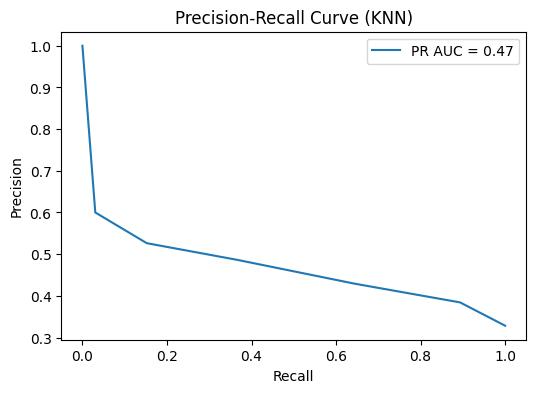

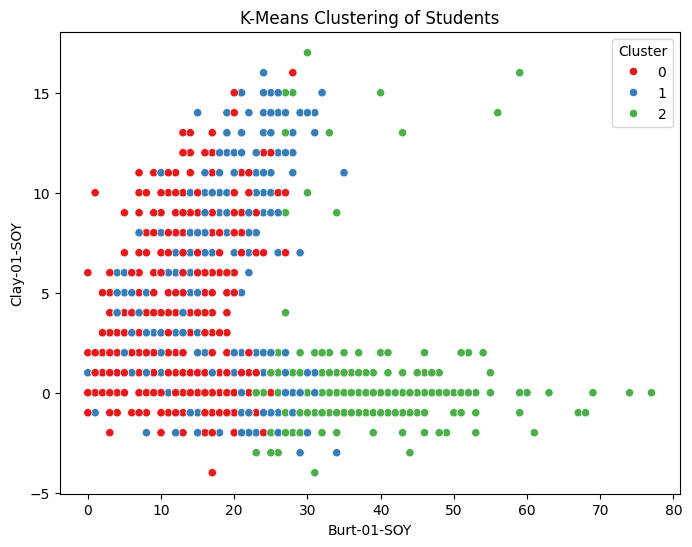

In [ ]:
main(df)

In [ ]:
def prepare_data(df):
    feature_columns = [
        'Burt-01-SOY', 'Burt-01-EOY', 'Clay-01-SOY', 'Clay-01-EOY',
        'TextLevel-01-SOY', 'TextLevel-01-EOY', 'WritingVocab-01-SOY',
        'Counting-01', 'Counting-02', 'Place Value-01', 'Place Value-02',
        'Addition and Subtraction-01', 'Multiplication and Division-01',
        '01.SES', '02.SES', 'NumSibling', 'SiblingOrder',
        'NumAbvYear9', 'NumAbvDiploma', 'NumProf', 'Disability', 'NCCD-Funded'
    ]

    X = df[feature_columns]
    y = df['Year3_Writing_At_Risk'].astype(int)
    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)
    return train_test_split(X_imputed, y, test_size=0.3, random_state=42)


Gradient Boosting Classifier Evaluation:
Accuracy: 0.71
ROC-AUC Score: 0.74
F1 Score: 0.46
Confusion Matrix:
[[355  48]
 [124  73]]

K-Nearest Neighbors Classifier Evaluation:
Accuracy: 0.67
Precision-Recall AUC: 0.53
F1 Score: 0.45
Confusion Matrix:
[[321  82]
 [117  80]]


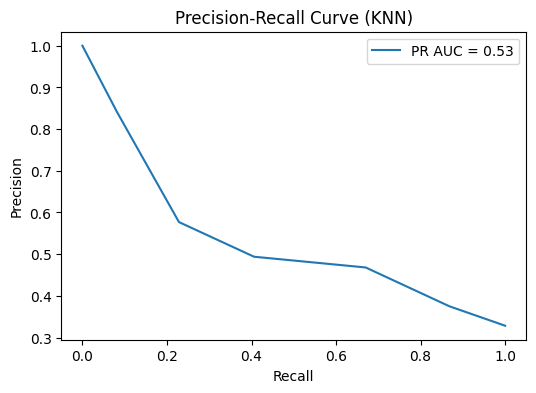

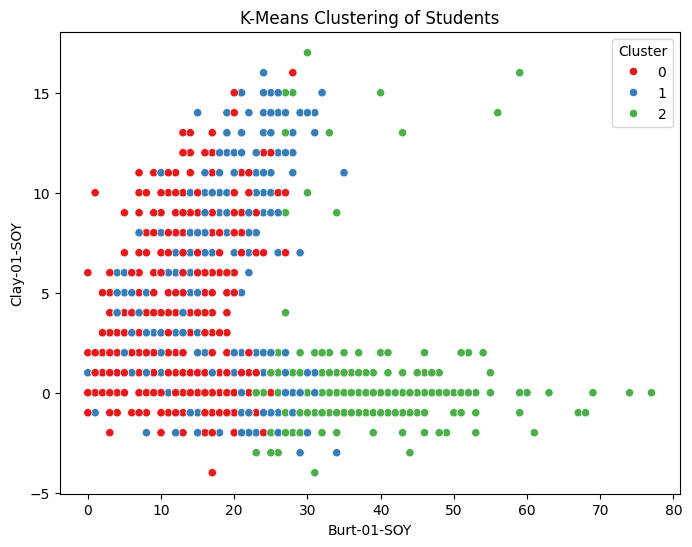

In [ ]:
from sklearn.impute import SimpleImputer
main(df)